# 04 · Dataset Maestro V2 — Obras + Empresas + Funcionarios

Este notebook construye un **dataset maestro** para el proyecto de detección y priorización de riesgos de corrupción en obras públicas.

## Objetivo

Integrar tres datasets previamente generados:

- Dataset de **obra**
- Dataset de **empresa**
- Dataset de **funcionario / miembro**

La unidad final del dataset maestro será:

> **1 fila = 1 IDENTIFICADOR_OBRA**

El target principal será:

> `y_riesgo_obra_4niveles`

con 4 niveles ordinales:

| Clase | Descripción |
|---:|---|
| 0 | Sin riesgo |
| 1 | Bajo riesgo |
| 2 | Medio riesgo |
| 3 | Alto / extremo riesgo |

## Principios técnicos

- No se hacen joins many-to-many directos.
- Empresa y funcionario se agregan primero por obra.
- Se verifica la existencia y estructura de cada dataset antes de integrarlo.
- Se normalizan llaves y nombres de columnas.
- Si empresa o funcionario no tienen `IDENTIFICADOR_OBRA`, se intenta mapear desde `CODIGO_OBRA`.
- Se genera baseline multiclase como validación inicial.

In [2]:
from pathlib import Path
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

# ============================================================
# CONFIGURACIÓN DE RUTA
# ============================================================

BASE = Path(r"C:\IA_Investigacion\Deteccion_Corrupcion")

# Para producción , comentamos la línea anterior y usamos esta función:
# def find_project_root(start: Path | None = None) -> Path:
#     start = start or Path.cwd()
#     for c in [start, *start.parents]:
#         if (c / "README.md").exists() and (c / "data").exists():
#             return c
#     raise FileNotFoundError("No se encontró la raíz del proyecto.")
# BASE = find_project_root()

DATA_PROC = BASE / "data" / "processed"
REPORTS = BASE / "reports" / "figures"
MODELS = BASE / "models" / "experiments"

DATA_PROC.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("DATA_PROC:", DATA_PROC)
print("REPORTS:", REPORTS)
print("MODELS:", MODELS)

BASE: C:\IA_Investigacion\Deteccion_Corrupcion
DATA_PROC: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed
REPORTS: C:\IA_Investigacion\Deteccion_Corrupcion\reports\figures
MODELS: C:\IA_Investigacion\Deteccion_Corrupcion\models\experiments


## 1. Rutas esperadas de datasets procesados

El notebook espera que ya existan los datasets generados previamente para obra, empresa y funcionario.

Si alguno no existe, el notebook lo reportará antes de fallar.

In [6]:
# ============================================================
# RUTAS DE INSUMOS
# ============================================================

PATH_OBRA = DATA_PROC / "dataset_obras_v3_4niveles_participante.parquet"
PATH_EMPRESA = DATA_PROC / "dataset_empresa_v3_4niveles_model.parquet"
PATH_FUNC = DATA_PROC / "dataset_funcionario_v3_4niveles_model.parquet"

INPUTS = {
    "obra": PATH_OBRA,
    "empresa": PATH_EMPRESA,
    "funcionario": PATH_FUNC,
}

for name, path in INPUTS.items():
    print(f"{name:12s} -> {path} | existe={path.exists()}")

obra         -> C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_obras_v3_4niveles_participante.parquet | existe=True
empresa      -> C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v3_4niveles_model.parquet | existe=True
funcionario  -> C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v3_4niveles_model.parquet | existe=True


## 2. Funciones utilitarias

In [4]:
# ============================================================
# FUNCIONES UTILITARIAS
# ============================================================

def read_table(path: Path) -> pd.DataFrame:
    """Lee parquet o csv."""
    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)

    if path.suffix.lower() == ".csv":
        for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
            try:
                return pd.read_csv(path, encoding=enc)
            except UnicodeDecodeError:
                continue
        return pd.read_csv(path, encoding="latin1")

    raise ValueError(f"Formato no soportado: {path.suffix}")


def find_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Busca una columna considerando mayúsculas/minúsculas y espacios."""
    normalized = {str(c).strip().lower(): c for c in df.columns}
    for cand in candidates:
        key = cand.strip().lower()
        if key in normalized:
            return normalized[key]
    return None


def clean_id(s: pd.Series) -> pd.Series:
    """Normaliza identificadores como string."""
    return (
        s.astype(str)
         .str.strip()
         .str.replace(r"\.0$", "", regex=True)
         .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )


def normalize_col(df: pd.DataFrame, candidates: list[str], final_name: str, required: bool = False) -> pd.DataFrame:
    """Renombra una columna si existe en candidatos y normaliza como string."""
    df = df.copy()
    col = find_col(df, candidates)
    if col is None:
        if required:
            raise KeyError(f"No se encontró columna requerida para {final_name}. Candidatas: {candidates}")
        return df
    if col != final_name:
        df = df.rename(columns={col: final_name})
    df[final_name] = clean_id(df[final_name])
    return df


def normalize_identificador(df: pd.DataFrame, required: bool = False) -> pd.DataFrame:
    return normalize_col(
        df,
        ["IDENTIFICADOR_OBRA", "Identificador_Obra", "identificador_obra", "Identificador Obra"],
        "IDENTIFICADOR_OBRA",
        required=required,
    )


def normalize_codigo_obra(df: pd.DataFrame, required: bool = False) -> pd.DataFrame:
    return normalize_col(
        df,
        ["CODIGO_OBRA", "Codigo_Obra", "codigo_obra", "COD_OBRA", "cod_obra"],
        "CODIGO_OBRA",
        required=required,
    )


def normalize_codigo_unico(df: pd.DataFrame, required: bool = False) -> pd.DataFrame:
    return normalize_col(
        df,
        ["CODIGO_UNICO", "Codigo_Unico", "codigo_unico", "COD_UNICO", "cod_unico"],
        "CODIGO_UNICO",
        required=required,
    )


def normalize_ruc(df: pd.DataFrame, required: bool = False) -> pd.DataFrame:
    return normalize_col(
        df,
        [
            "CODIGO_RUC",
            "codigo_ruc",
            "RUC",
            "ruc",
            "CODIGO_RUC_EMPRESA",
            "CODIGO_RUC_GANADOR",
            "CODIGO_RUC_PARTICIPANTE",
            "RUC_GANADOR",
            "RUC_PARTICIPANTE",
        ],
        "CODIGO_RUC",
        required=required,
    )


def normalize_dni(df: pd.DataFrame, required: bool = False) -> pd.DataFrame:
    return normalize_col(
        df,
        [
            "CODIGO_DNI",
            "codigo_dni",
            "DNI",
            "dni",
            "DNI_MIEMBRO_COMITE",
            "DOCUMENTO_IDENTIDAD",
            "DOC_IDENTIDAD",
        ],
        "CODIGO_DNI",
        required=required,
    )


def dataset_summary(name: str, df: pd.DataFrame) -> pd.DataFrame:
    rows = [
        {"dataset": name, "metrica": "filas", "valor": len(df)},
        {"dataset": name, "metrica": "columnas", "valor": df.shape[1]},
        {"dataset": name, "metrica": "duplicados_fila", "valor": int(df.duplicated().sum())},
    ]

    for key in ["IDENTIFICADOR_OBRA", "CODIGO_OBRA", "CODIGO_UNICO", "CODIGO_RUC", "CODIGO_DNI"]:
        rows.append({"dataset": name, "metrica": f"{key}_existe", "valor": key in df.columns})
        if key in df.columns:
            rows.append({"dataset": name, "metrica": f"{key}_nunique", "valor": df[key].nunique(dropna=True)})
            rows.append({"dataset": name, "metrica": f"{key}_nulos", "valor": int(df[key].isna().sum())})

    return pd.DataFrame(rows)


def print_cols(name: str, df: pd.DataFrame, max_cols: int = 80):
    print(f"\nColumnas {name} ({df.shape[1]}):")
    cols = list(df.columns)
    print(cols[:max_cols])
    if len(cols) > max_cols:
        print(f"... {len(cols) - max_cols} columnas adicionales")

## 3. Carga de datasets y verificación inicial

In [7]:
# ============================================================
# CARGA DE DATASETS
# ============================================================

df_obra = read_table(PATH_OBRA)
df_empresa = read_table(PATH_EMPRESA)
df_func = read_table(PATH_FUNC)

print("Shape obra:", df_obra.shape)
print("Shape empresa:", df_empresa.shape)
print("Shape funcionario:", df_func.shape)

display(pd.concat([
    dataset_summary("obra", df_obra),
    dataset_summary("empresa", df_empresa),
    dataset_summary("funcionario", df_func),
], ignore_index=True))

print_cols("obra", df_obra)
print_cols("empresa", df_empresa)
print_cols("funcionario", df_func)

Shape obra: (5249, 34)
Shape empresa: (8047, 26)
Shape funcionario: (4219, 13)


,dataset,metrica,valor
0,obra,filas,5249
1,obra,columnas,34
2,obra,duplicados_fila,0
3,obra,IDENTIFICADOR_OBRA_existe,True
4,obra,IDENTIFICADOR_OBRA_nunique,324
5,obra,IDENTIFICADOR_OBRA_nulos,0
6,obra,CODIGO_OBRA_existe,True
7,obra,CODIGO_OBRA_nunique,230
8,obra,CODIGO_OBRA_nulos,0
9,obra,CODIGO_UNICO_existe,True



Columnas obra (34):
['CODIGO_UNICO', 'SECTOR', 'DEPARTAMENTO', 'NIVEL_GOBIERNO', 'IDENTIFICADOR_OBRA', 'PROCESO', 'OBJETO_PROCESO', 'CODIGO_OBRA', 'NOMBREOBRA', 'METODO_CONTRATACION', 'CODIGO_RUC_GANADOR', 'RAZON_SOCIAL', 'CONVOCATORIA_PROCESO_GANADO', 'TotalProcesosParticipantes', 'CODIGO_CONTRATO', 'NUMERO_CONTRATO', 'CODIGO_RUC_PARTICIPANTE', 'NOMBRE_PARTICIPANTE', 'y_riesgo_4niveles', 'n_ofertas', 'monto_ofertado_min', 'monto_ofertado_max', 'monto_ofertado_mean', 'monto_ofertado_median', 'monto_ofertado_std', 'monto_ofertado_rango', 'obra_2a3a_n_registros', 'obra_2a3a_nunique_CODIGO_RUC', 'obra_2a3a_nunique_MIEMBROS_DE_COMITE', 'obra_2a3a_nunique_TotalProcesosParticipantes', 'obra_2b_n_registros', 'obra_2b_nunique_DNI_MIEMBRO_COMITE', 'obra_2b_nunique_NOMBRE_MIEMBRO_COMITE', 'obra_5a_n_registros']

Columnas empresa (26):
['CODIGO_RUC', 'NOMBRE_EMPRESA_ROL', 'RUC_CONTRAPARTE', 'NOMBRE_CONTRAPARTE', 'rol_empresa', 'n_obras_asociadas_1a', 'n_registros_1a', 'es_consorcio', 'capacidad_

## 4. Normalización ordenada de llaves

La tabla de obra es la tabla madre. Empresa y funcionario pueden venir con `IDENTIFICADOR_OBRA` o solo con `CODIGO_OBRA`.

In [8]:
# ============================================================
# NORMALIZACIÓN DE OBRA
# ============================================================

df_obra = normalize_identificador(df_obra, required=True)
df_obra = normalize_codigo_obra(df_obra, required=False)
df_obra = normalize_codigo_unico(df_obra, required=False)

target_candidates = [
    "y_riesgo_obra_4niveles",
    "y_riesgo_4niveles",
    "y_riesgo_nivel_4",
    "y_riesgo_nivel",
]

target_col = find_col(df_obra, target_candidates)
if target_col is None:
    raise KeyError(
        f"No se encontró target de obra. Candidatos: {target_candidates}. "
        "Verifica que el dataset de obra V3 tenga target de 4 niveles."
    )

if target_col != "y_riesgo_obra_4niveles":
    df_obra = df_obra.rename(columns={target_col: "y_riesgo_obra_4niveles"})

df_obra["y_riesgo_obra_4niveles"] = pd.to_numeric(
    df_obra["y_riesgo_obra_4niveles"], errors="coerce"
).astype("Int64")

print("Target obra:", "y_riesgo_obra_4niveles")
print(df_obra["y_riesgo_obra_4niveles"].value_counts().sort_index())

# Crear mapa obra si existe CODIGO_OBRA
mapa_obra = None
if "CODIGO_OBRA" in df_obra.columns:
    mapa_obra = (
        df_obra[["CODIGO_OBRA", "IDENTIFICADOR_OBRA"]]
        .dropna(subset=["CODIGO_OBRA", "IDENTIFICADOR_OBRA"])
        .drop_duplicates()
    )

    conflictos = mapa_obra.groupby("CODIGO_OBRA")["IDENTIFICADOR_OBRA"].nunique()
    n_conflictos = int((conflictos > 1).sum())
    print("Mapa CODIGO_OBRA → IDENTIFICADOR_OBRA:", mapa_obra.shape)
    print("CODIGO_OBRA con múltiples IDENTIFICADOR_OBRA:", n_conflictos)

    mapa_obra = mapa_obra.drop_duplicates("CODIGO_OBRA")
else:
    print("ADVERTENCIA: df_obra no tiene CODIGO_OBRA. No se podrá mapear empresa/funcionario por CODIGO_OBRA.")

Target obra: y_riesgo_obra_4niveles
y_riesgo_obra_4niveles
0     168
1    1287
2    1792
3    2002
Name: count, dtype: Int64
Mapa CODIGO_OBRA → IDENTIFICADOR_OBRA: (324, 2)
CODIGO_OBRA con múltiples IDENTIFICADOR_OBRA: 77


In [9]:
# ============================================================
# NORMALIZACIÓN DE EMPRESA
# ============================================================

df_empresa = normalize_identificador(df_empresa, required=False)
df_empresa = normalize_codigo_obra(df_empresa, required=False)
df_empresa = normalize_ruc(df_empresa, required=False)

if "IDENTIFICADOR_OBRA" not in df_empresa.columns:
    if "CODIGO_OBRA" in df_empresa.columns and mapa_obra is not None:
        print("🔄 Empresa: mapeando CODIGO_OBRA → IDENTIFICADOR_OBRA")
        before = len(df_empresa)
        df_empresa = df_empresa.merge(mapa_obra, on="CODIGO_OBRA", how="left")
        print("Filas empresa:", before, "->", len(df_empresa))
        print("Empresa con IDENTIFICADOR_OBRA:", int(df_empresa["IDENTIFICADOR_OBRA"].notna().sum()))
        print("Empresa sin IDENTIFICADOR_OBRA:", int(df_empresa["IDENTIFICADOR_OBRA"].isna().sum()))
    else:
        print("⚠ Empresa no tiene IDENTIFICADOR_OBRA ni puente CODIGO_OBRA usable.")

df_empresa = normalize_identificador(df_empresa, required=False)

empresa_target_candidates = [
    "y_riesgo_empresa",
    "y_riesgo_empresa_4niveles",
    "riesgo_empresa_4niveles",
]

empresa_target_col = find_col(df_empresa, empresa_target_candidates)
if empresa_target_col is not None and empresa_target_col != "y_riesgo_empresa":
    df_empresa = df_empresa.rename(columns={empresa_target_col: "y_riesgo_empresa"})

if "y_riesgo_empresa" in df_empresa.columns:
    df_empresa["y_riesgo_empresa"] = pd.to_numeric(df_empresa["y_riesgo_empresa"], errors="coerce")
else:
    print("⚠ No se encontró y_riesgo_empresa. Se crearán agregados solo con conteos de empresa.")

⚠ Empresa no tiene IDENTIFICADOR_OBRA ni puente CODIGO_OBRA usable.


In [10]:
# ============================================================
# NORMALIZACIÓN DE FUNCIONARIO
# ============================================================

df_func = normalize_identificador(df_func, required=False)
df_func = normalize_codigo_obra(df_func, required=False)
df_func = normalize_dni(df_func, required=False)

if "IDENTIFICADOR_OBRA" not in df_func.columns:
    if "CODIGO_OBRA" in df_func.columns and mapa_obra is not None:
        print("🔄 Funcionario: mapeando CODIGO_OBRA → IDENTIFICADOR_OBRA")
        before = len(df_func)
        df_func = df_func.merge(mapa_obra, on="CODIGO_OBRA", how="left")
        print("Filas funcionario:", before, "->", len(df_func))
        print("Funcionario con IDENTIFICADOR_OBRA:", int(df_func["IDENTIFICADOR_OBRA"].notna().sum()))
        print("Funcionario sin IDENTIFICADOR_OBRA:", int(df_func["IDENTIFICADOR_OBRA"].isna().sum()))
    else:
        print("⚠ Funcionario no tiene IDENTIFICADOR_OBRA ni puente CODIGO_OBRA usable.")

df_func = normalize_identificador(df_func, required=False)

func_target_candidates = [
    "y_riesgo_funcionario",
    "y_riesgo_funcionario_4niveles",
    "riesgo_funcionario_4niveles",
]

func_target_col = find_col(df_func, func_target_candidates)
if func_target_col is not None and func_target_col != "y_riesgo_funcionario":
    df_func = df_func.rename(columns={func_target_col: "y_riesgo_funcionario"})

if "y_riesgo_funcionario" in df_func.columns:
    df_func["y_riesgo_funcionario"] = pd.to_numeric(df_func["y_riesgo_funcionario"], errors="coerce")
else:
    print("⚠ No se encontró y_riesgo_funcionario. Se crearán agregados solo con conteos de funcionario.")

🔄 Funcionario: mapeando CODIGO_OBRA → IDENTIFICADOR_OBRA
Filas funcionario: 4219 -> 4219
Funcionario con IDENTIFICADOR_OBRA: 1601
Funcionario sin IDENTIFICADOR_OBRA: 2618


## 5. Verificación posterior a normalización

In [11]:
# ============================================================
# VERIFICACIÓN DE LLAVES POST-NORMALIZACIÓN
# ============================================================

resumen_post = pd.concat([
    dataset_summary("obra_norm", df_obra),
    dataset_summary("empresa_norm", df_empresa),
    dataset_summary("funcionario_norm", df_func),
], ignore_index=True)

display(resumen_post)

print("\nObras únicas en obra:", df_obra["IDENTIFICADOR_OBRA"].nunique(dropna=True))

if "IDENTIFICADOR_OBRA" in df_empresa.columns:
    print("Obras únicas en empresa:", df_empresa["IDENTIFICADOR_OBRA"].nunique(dropna=True))
else:
    print("Obras únicas en empresa: no disponible")

if "IDENTIFICADOR_OBRA" in df_func.columns:
    print("Obras únicas en funcionario:", df_func["IDENTIFICADOR_OBRA"].nunique(dropna=True))
else:
    print("Obras únicas en funcionario: no disponible")

obra_ids = set(df_obra["IDENTIFICADOR_OBRA"].dropna().unique())

if "IDENTIFICADOR_OBRA" in df_empresa.columns:
    emp_ids = set(df_empresa["IDENTIFICADOR_OBRA"].dropna().unique())
    print("Cobertura empresa sobre obra:", len(obra_ids & emp_ids), "/", len(obra_ids), "obras")

if "IDENTIFICADOR_OBRA" in df_func.columns:
    func_ids = set(df_func["IDENTIFICADOR_OBRA"].dropna().unique())
    print("Cobertura funcionario sobre obra:", len(obra_ids & func_ids), "/", len(obra_ids), "obras")

,dataset,metrica,valor
0,obra_norm,filas,5249
1,obra_norm,columnas,34
2,obra_norm,duplicados_fila,0
3,obra_norm,IDENTIFICADOR_OBRA_existe,True
4,obra_norm,IDENTIFICADOR_OBRA_nunique,324
5,obra_norm,IDENTIFICADOR_OBRA_nulos,0
6,obra_norm,CODIGO_OBRA_existe,True
7,obra_norm,CODIGO_OBRA_nunique,230
8,obra_norm,CODIGO_OBRA_nulos,0
9,obra_norm,CODIGO_UNICO_existe,True



Obras únicas en obra: 324
Obras únicas en empresa: no disponible
Obras únicas en funcionario: 176
Cobertura funcionario sobre obra: 176 / 324 obras


## 6. Construcción de base de obra

Se reduce el dataset de obra a una fila por `IDENTIFICADOR_OBRA`.

In [12]:
# ============================================================
# BASE DE OBRA A NIVEL IDENTIFICADOR_OBRA
# ============================================================

obra_leakage = [
    "RIESGO_OBRA",
    "RIESGO_DESCRIPCION_OBRA",
    "y_riesgo",
    "y_riesgo_binario",
    "y_riesgo_alto",
    "y_riesgo_nivel",
]

target_por_obra = (
    df_obra[["IDENTIFICADOR_OBRA", "y_riesgo_obra_4niveles"]]
    .dropna(subset=["IDENTIFICADOR_OBRA"])
    .drop_duplicates("IDENTIFICADOR_OBRA")
)

obra_features_raw = df_obra.drop(columns=[c for c in obra_leakage if c in df_obra.columns], errors="ignore")
obra_features_raw = obra_features_raw.drop(columns=["y_riesgo_obra_4niveles"], errors="ignore")

id_col = "IDENTIFICADOR_OBRA"

num_cols_obra = [
    c for c in obra_features_raw.select_dtypes(include=["number"]).columns
    if c != id_col
]

cat_cols_obra = [
    c for c in obra_features_raw.select_dtypes(include=["object", "category", "bool"]).columns
    if c != id_col
]

agg_dict = {}

for c in num_cols_obra:
    agg_dict[f"obra_{c}_mean"] = (c, "mean")
    agg_dict[f"obra_{c}_max"] = (c, "max")
    agg_dict[f"obra_{c}_min"] = (c, "min")

for c in cat_cols_obra:
    if c not in ["CODIGO_RUC", "CODIGO_DNI"]:
        agg_dict[f"obra_{c}_first"] = (c, lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan)
        agg_dict[f"obra_{c}_nunique"] = (c, "nunique")

df_obra_base = (
    obra_features_raw
    .dropna(subset=["IDENTIFICADOR_OBRA"])
    .groupby("IDENTIFICADOR_OBRA")
    .agg(**agg_dict)
    .reset_index()
)

df_obra_base = df_obra_base.merge(target_por_obra, on="IDENTIFICADOR_OBRA", how="left")

print("df_obra_base:", df_obra_base.shape)
print(df_obra_base["y_riesgo_obra_4niveles"].value_counts().sort_index())
display(df_obra_base.head())

df_obra_base: (324, 87)
y_riesgo_obra_4niveles
0     31
1     52
2     87
3    154
Name: count, dtype: Int64


,IDENTIFICADOR_OBRA,obra_PROCESO_mean,obra_PROCESO_max,obra_PROCESO_min,obra_CODIGO_RUC_GANADOR_mean,obra_CODIGO_RUC_GANADOR_max,obra_CODIGO_RUC_GANADOR_min,obra_CONVOCATORIA_PROCESO_GANADO_mean,obra_CONVOCATORIA_PROCESO_GANADO_max,obra_CONVOCATORIA_PROCESO_GANADO_min,...,obra_NOMBREOBRA_nunique,obra_METODO_CONTRATACION_first,obra_METODO_CONTRATACION_nunique,obra_RAZON_SOCIAL_first,obra_RAZON_SOCIAL_nunique,obra_NUMERO_CONTRATO_first,obra_NUMERO_CONTRATO_nunique,obra_NOMBRE_PARTICIPANTE_first,obra_NOMBRE_PARTICIPANTE_nunique,y_riesgo_obra_4niveles
0,2002060-2434-702592-2064311-19777,3.0,3,3,2.054932e+10,20549322434,20549322434,702592.0,702592,702592,...,1,Concurso Público,1,VERA & MORENO S.A. CONSULTORES DE INGENIERIA(*),6,063-2021-MTC/20.2,1,VERA & MORENO S.A. CONSULTORES DE INGENIERIA(*),6,3
1,2002210-8880-869397-2169938-826,60.0,60,60,2.052240e+10,20522404331,20522404331,869397.0,869397,869397,...,1,Concurso Público,1,consorcio consultor peajes,14,022-2023-MTC/20.2,1,consorcio consultor peajes,14,2
2,2002210-8880-870112-2169901-826,60.0,60,60,2.052898e+10,20528975055,20528975055,870112.0,870112,870112,...,1,Concurso Público,1,consorcio consultor peajes,13,015-2023-MTC/20.2,1,consorcio consultor peajes,13,2
3,2026767-16256-709096-2067605-143536,14.0,14,14,2.041669e+10,20419183220,20414192531,709096.0,709096,709096,...,1,Concurso Público,1,KUKOVA INGENIEROS S.A.C.(*),10,072-2021-MTC/20.2,1,KUKOVA INGENIEROS S.A.C.(*),10,3
4,2027711-3876-682536-2050524-138320,39.0,39,39,2.055223e+10,20552233787,20552233787,682536.0,682536,682536,...,1,Concurso Público,1,LAGESA INGENIEROS CONSULTORES S.A.,22,045-2021-MTC/20.2,1,LAGESA INGENIEROS CONSULTORES S.A.,22,3


## 7. Agregados de empresa por obra

In [13]:
# ============================================================
# AGREGADOS DE EMPRESA POR OBRA
# ============================================================

def build_empresa_agg(df: pd.DataFrame) -> pd.DataFrame:
    if "IDENTIFICADOR_OBRA" not in df.columns:
        print("Empresa no tiene IDENTIFICADOR_OBRA. Se devuelve dataframe vacío.")
        return pd.DataFrame({"IDENTIFICADOR_OBRA": []})

    df = df.dropna(subset=["IDENTIFICADOR_OBRA"]).copy()

    if len(df) == 0:
        return pd.DataFrame({"IDENTIFICADOR_OBRA": []})

    if "CODIGO_RUC" not in df.columns:
        df["CODIGO_RUC"] = np.nan

    agg = df.groupby("IDENTIFICADOR_OBRA").agg(
        emp_n_registros=("IDENTIFICADOR_OBRA", "size"),
        emp_n_empresas=("CODIGO_RUC", "nunique"),
    ).reset_index()

    if "y_riesgo_empresa" in df.columns:
        riesgo_agg = df.groupby("IDENTIFICADOR_OBRA").agg(
            emp_riesgo_max=("y_riesgo_empresa", "max"),
            emp_riesgo_mean=("y_riesgo_empresa", "mean"),
            emp_riesgo_std=("y_riesgo_empresa", "std"),
            emp_pct_riesgo_alto=("y_riesgo_empresa", lambda x: np.mean(pd.to_numeric(x, errors="coerce") >= 3)),
        ).reset_index()
        agg = agg.merge(riesgo_agg, on="IDENTIFICADOR_OBRA", how="left")

    return agg


empresa_agg = build_empresa_agg(df_empresa)

print("empresa_agg:", empresa_agg.shape)
display(empresa_agg.head())

Empresa no tiene IDENTIFICADOR_OBRA. Se devuelve dataframe vacío.
empresa_agg: (0, 1)


,IDENTIFICADOR_OBRA


## 8. Agregados de funcionario por obra

In [14]:
# ============================================================
# AGREGADOS DE FUNCIONARIO POR OBRA
# ============================================================

def build_func_agg(df: pd.DataFrame) -> pd.DataFrame:
    if "IDENTIFICADOR_OBRA" not in df.columns:
        print("Funcionario no tiene IDENTIFICADOR_OBRA. Se devuelve dataframe vacío.")
        return pd.DataFrame({"IDENTIFICADOR_OBRA": []})

    df = df.dropna(subset=["IDENTIFICADOR_OBRA"]).copy()

    if len(df) == 0:
        return pd.DataFrame({"IDENTIFICADOR_OBRA": []})

    if "CODIGO_DNI" not in df.columns:
        df["CODIGO_DNI"] = np.nan

    agg = df.groupby("IDENTIFICADOR_OBRA").agg(
        func_n_registros=("IDENTIFICADOR_OBRA", "size"),
        func_n_funcionarios=("CODIGO_DNI", "nunique"),
    ).reset_index()

    if "y_riesgo_funcionario" in df.columns:
        riesgo_agg = df.groupby("IDENTIFICADOR_OBRA").agg(
            func_riesgo_max=("y_riesgo_funcionario", "max"),
            func_riesgo_mean=("y_riesgo_funcionario", "mean"),
            func_riesgo_std=("y_riesgo_funcionario", "std"),
            func_pct_riesgo_alto=("y_riesgo_funcionario", lambda x: np.mean(pd.to_numeric(x, errors="coerce") >= 3)),
        ).reset_index()
        agg = agg.merge(riesgo_agg, on="IDENTIFICADOR_OBRA", how="left")

    return agg


func_agg = build_func_agg(df_func)

print("func_agg:", func_agg.shape)
display(func_agg.head())

func_agg: (176, 7)


,IDENTIFICADOR_OBRA,func_n_registros,func_n_funcionarios,func_riesgo_max,func_riesgo_mean,func_riesgo_std,func_pct_riesgo_alto
0,2002060-2434-702592-2064311-19777,6,6,3,1.166667,1.329160,0.166667
1,2002210-8880-869397-2169938-826,12,6,0,0.000000,0.000000,0.000000
2,2026767-16256-709096-2067605-143536,6,6,3,0.500000,1.224745,0.166667
3,2027711-3876-682536-2050524-138320,12,11,3,0.666667,1.230915,0.166667
4,2029683-3527-639021-2017003-43642,6,6,3,0.500000,1.224745,0.166667


## 9. Integración del dataset maestro

In [15]:
# ============================================================
# MERGE MAESTRO
# ============================================================

df_master = df_obra_base.copy()

if len(empresa_agg) > 0:
    df_master = df_master.merge(empresa_agg, on="IDENTIFICADOR_OBRA", how="left")

if len(func_agg) > 0:
    df_master = df_master.merge(func_agg, on="IDENTIFICADOR_OBRA", how="left")

agg_prefixes = ("emp_", "func_")
agg_cols = [c for c in df_master.columns if c.startswith(agg_prefixes)]
df_master[agg_cols] = df_master[agg_cols].fillna(0)

assert df_master["IDENTIFICADOR_OBRA"].is_unique, "El dataset maestro tiene obras duplicadas."

print("df_master:", df_master.shape)
print("Obras únicas:", df_master["IDENTIFICADOR_OBRA"].nunique())
print("Distribución target:")
print(df_master["y_riesgo_obra_4niveles"].value_counts().sort_index())

display(df_master.head())

df_master: (324, 93)
Obras únicas: 324
Distribución target:
y_riesgo_obra_4niveles
0     31
1     52
2     87
3    154
Name: count, dtype: Int64


,IDENTIFICADOR_OBRA,obra_PROCESO_mean,obra_PROCESO_max,obra_PROCESO_min,obra_CODIGO_RUC_GANADOR_mean,obra_CODIGO_RUC_GANADOR_max,obra_CODIGO_RUC_GANADOR_min,obra_CONVOCATORIA_PROCESO_GANADO_mean,obra_CONVOCATORIA_PROCESO_GANADO_max,obra_CONVOCATORIA_PROCESO_GANADO_min,...,obra_NUMERO_CONTRATO_nunique,obra_NOMBRE_PARTICIPANTE_first,obra_NOMBRE_PARTICIPANTE_nunique,y_riesgo_obra_4niveles,func_n_registros,func_n_funcionarios,func_riesgo_max,func_riesgo_mean,func_riesgo_std,func_pct_riesgo_alto
0,2002060-2434-702592-2064311-19777,3.0,3,3,2.054932e+10,20549322434,20549322434,702592.0,702592,702592,...,1,VERA & MORENO S.A. CONSULTORES DE INGENIERIA(*),6,3,6.0,6.0,3.0,1.166667,1.329160,0.166667
1,2002210-8880-869397-2169938-826,60.0,60,60,2.052240e+10,20522404331,20522404331,869397.0,869397,869397,...,1,consorcio consultor peajes,14,2,12.0,6.0,0.0,0.000000,0.000000,0.000000
2,2002210-8880-870112-2169901-826,60.0,60,60,2.052898e+10,20528975055,20528975055,870112.0,870112,870112,...,1,consorcio consultor peajes,13,2,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,2026767-16256-709096-2067605-143536,14.0,14,14,2.041669e+10,20419183220,20414192531,709096.0,709096,709096,...,1,KUKOVA INGENIEROS S.A.C.(*),10,3,6.0,6.0,3.0,0.500000,1.224745,0.166667
4,2027711-3876-682536-2050524-138320,39.0,39,39,2.055223e+10,20552233787,20552233787,682536.0,682536,682536,...,1,LAGESA INGENIEROS CONSULTORES S.A.,22,3,12.0,11.0,3.0,0.666667,1.230915,0.166667


## 10. EDA mínimo del dataset maestro

Shape: (324, 93)

Target:
y_riesgo_obra_4niveles
0     31
1     52
2     87
3    154
Name: count, dtype: Int64

Nulos principales:


obra_monto_ofertado_std_max                        72
obra_monto_ofertado_std_min                        72
obra_monto_ofertado_std_mean                       72
obra_obra_2b_n_registros_mean                      67
obra_obra_2b_nunique_DNI_MIEMBRO_COMITE_min        67
obra_obra_2b_nunique_NOMBRE_MIEMBRO_COMITE_min     67
obra_obra_2b_nunique_NOMBRE_MIEMBRO_COMITE_max     67
obra_obra_2b_nunique_NOMBRE_MIEMBRO_COMITE_mean    67
obra_obra_2b_n_registros_max                       67
obra_obra_2b_nunique_DNI_MIEMBRO_COMITE_max        67
obra_obra_2b_nunique_DNI_MIEMBRO_COMITE_mean       67
obra_obra_2b_n_registros_min                       67
IDENTIFICADOR_OBRA                                  0
obra_CODIGO_CONTRATO_mean                           0
obra_CODIGO_CONTRATO_max                            0
obra_CODIGO_CONTRATO_min                            0
obra_CODIGO_RUC_PARTICIPANTE_mean                   0
obra_PROCESO_mean                                   0
obra_PROCESO_max            


Describe numérico:


,count,mean,std,min,25%,50%,75%,max
obra_PROCESO_mean,324.0,18.901235,40.053325,1.0,3.0,6.5,19.0,539.0
obra_PROCESO_max,324.0,18.901235,40.053325,1.0,3.0,6.5,19.0,539.0
obra_PROCESO_min,324.0,18.901235,40.053325,1.0,3.0,6.5,19.0,539.0
obra_CODIGO_RUC_GANADOR_mean,324.0,17871493974.40239,4104753620.018068,10011600447.0,15328281751.0,20425123115.0,20538686104.375,20610555609.0
obra_CODIGO_RUC_GANADOR_max,324.0,18510349761.953705,4046700996.153511,10011600447.0,20117264883.0,20519675467.0,20600540946.5,20610555609.0
obra_CODIGO_RUC_GANADOR_min,324.0,17238177316.919754,4736961556.013585,10001046191.0,10408987554.0,20301387332.5,20522899223.5,20610555609.0
obra_CONVOCATORIA_PROCESO_GANADO_mean,324.0,735331.762346,90767.221621,385171.0,671243.25,719921.0,807329.75,933575.0
obra_CONVOCATORIA_PROCESO_GANADO_max,324.0,735331.762346,90767.221621,385171.0,671243.25,719921.0,807329.75,933575.0
obra_CONVOCATORIA_PROCESO_GANADO_min,324.0,735331.762346,90767.221621,385171.0,671243.25,719921.0,807329.75,933575.0
obra_TotalProcesosParticipantes_mean,324.0,93.203807,80.185541,1.0,39.0,79.75,129.625,577.5


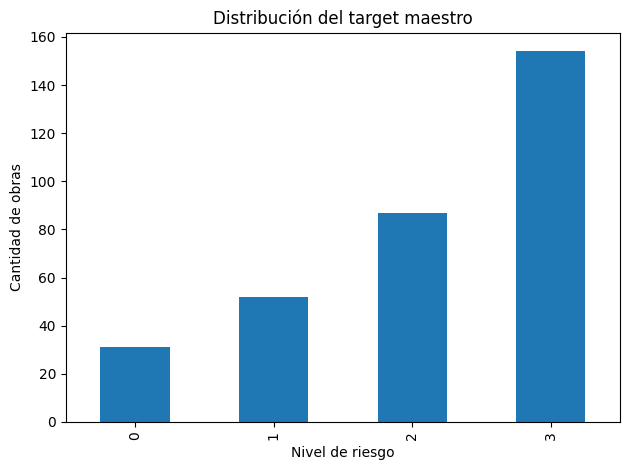

Figura guardada: C:\IA_Investigacion\Deteccion_Corrupcion\reports\figures\target_dataset_maestro_4niveles.png


In [16]:
# ============================================================
# EDA MÍNIMO
# ============================================================

print("Shape:", df_master.shape)
print("\nTarget:")
print(df_master["y_riesgo_obra_4niveles"].value_counts().sort_index())

print("\nNulos principales:")
display(df_master.isna().sum().sort_values(ascending=False).head(20))

print("\nDescribe numérico:")
display(df_master.describe(include=[np.number]).T.head(30))

if plt is not None:
    ax = df_master["y_riesgo_obra_4niveles"].value_counts().sort_index().plot(kind="bar", title="Distribución del target maestro")
    ax.set_xlabel("Nivel de riesgo")
    ax.set_ylabel("Cantidad de obras")
    plt.tight_layout()
    fig_path = REPORTS / "target_dataset_maestro_4niveles.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("Figura guardada:", fig_path)

## 11. Preparación para baseline

In [17]:
# ============================================================
# PREPARACIÓN MODELADO
# ============================================================

TARGET = "y_riesgo_obra_4niveles"

drop_cols = [
    TARGET,
    "IDENTIFICADOR_OBRA",
    "CODIGO_OBRA",
    "CODIGO_UNICO",
    "RIESGO_OBRA",
    "RIESGO_DESCRIPCION_OBRA",
    "y_riesgo",
    "y_riesgo_binario",
    "y_riesgo_alto",
    "y_riesgo_nivel",
]

existing_drop = [c for c in drop_cols if c in df_master.columns]

X = df_master.drop(columns=existing_drop, errors="ignore")
y = df_master[TARGET].astype(int)

all_nan_cols = [c for c in X.columns if X[c].isna().all()]
X = X.drop(columns=all_nan_cols)

const_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
X = X.drop(columns=const_cols)

print("X:", X.shape)
print("y:", y.shape)
print("Columnas eliminadas all_nan:", len(all_nan_cols))
print("Columnas eliminadas constantes:", len(const_cols))
print("Target:")
print(y.value_counts().sort_index())

X: (324, 82)
y: (324,)
Columnas eliminadas all_nan: 0
Columnas eliminadas constantes: 9
Target:
y_riesgo_obra_4niveles
0     31
1     52
2     87
3    154
Name: count, dtype: int64


## 12. Baseline multiclase

Num cols: 71
Cat cols: 11
Split estratificado habilitado.
{
  "accuracy": 0.2923076923076923,
  "balanced_accuracy": 0.23315412186379927,
  "macro_f1": 0.2261467086834734,
  "weighted_f1": 0.31369855634561516,
  "n_train": 259,
  "n_test": 65,
  "n_features": 82
}

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         6
           1     0.1364    0.3000    0.1875        10
           2     0.2941    0.2778    0.2857        18
           3     0.5500    0.3548    0.4314        31

    accuracy                         0.2923        65
   macro avg     0.2451    0.2332    0.2261        65
weighted avg     0.3647    0.2923    0.3137        65


Matriz de confusión:
[[ 0  4  2  0]
 [ 2  3  4  1]
 [ 2  3  5  8]
 [ 2 12  6 11]]


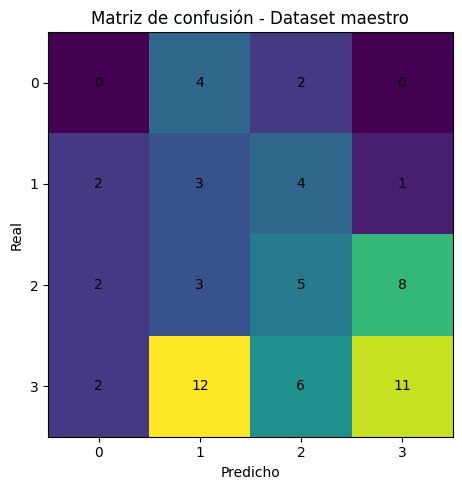

Figura guardada: C:\IA_Investigacion\Deteccion_Corrupcion\reports\figures\confusion_matrix_dataset_maestro_4niveles.png


In [18]:
# ============================================================
# BASELINE MULTICLASE
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Num cols:", len(num_cols))
print("Cat cols:", len(cat_cols))

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

clf = Pipeline([
    ("pre", pre),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42,
    )),
])

class_counts = y.value_counts()
can_stratify = class_counts.min() >= 2

if can_stratify:
    stratify_arg = y
    print("Split estratificado habilitado.")
else:
    stratify_arg = None
    print("ADVERTENCIA: alguna clase tiene menos de 2 registros. Split sin estratificación.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_arg,
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
    "macro_f1": float(f1_score(y_test, y_pred, average="macro")),
    "weighted_f1": float(f1_score(y_test, y_pred, average="weighted")),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "n_features": int(X.shape[1]),
}

print(json.dumps(metrics, indent=2, ensure_ascii=False))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
print("\nMatriz de confusión:")
print(cm)

if plt is not None:
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm)
    ax.set_title("Matriz de confusión - Dataset maestro")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    labels = sorted(y.unique())
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    fig_path = REPORTS / "confusion_matrix_dataset_maestro_4niveles.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print("Figura guardada:", fig_path)

## 13. Guardado de salidas

In [19]:
# ============================================================
# GUARDADO DE SALIDAS
# ============================================================

OUT_PARQUET = DATA_PROC / "dataset_maestro_v2_4niveles.parquet"
OUT_CSV = DATA_PROC / "dataset_maestro_v2_4niveles.csv"
OUT_META = DATA_PROC / "dataset_maestro_v2_4niveles_meta.json"
OUT_METRICS = DATA_PROC / "baseline_dataset_maestro_v2_4niveles_metrics.json"
OUT_MODEL = MODELS / "baseline_dataset_maestro_v2_4niveles_logreg.pkl"

df_master.to_parquet(OUT_PARQUET, index=False)
df_master.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

metadata = {
    "created_at": datetime.now().isoformat(),
    "unit_of_analysis": "IDENTIFICADOR_OBRA",
    "target": TARGET,
    "target_description": {
        "0": "Sin riesgo",
        "1": "Bajo riesgo",
        "2": "Medio riesgo",
        "3": "Alto / extremo riesgo",
    },
    "input_paths": {k: str(v) for k, v in INPUTS.items()},
    "shape_master": list(df_master.shape),
    "n_obras": int(df_master["IDENTIFICADOR_OBRA"].nunique()),
    "target_distribution": {str(k): int(v) for k, v in df_master[TARGET].value_counts().sort_index().items()},
    "empresa_agg_shape": list(empresa_agg.shape),
    "funcionario_agg_shape": list(func_agg.shape),
    "features_used_after_cleaning": list(X.columns),
    "n_features_used": int(X.shape[1]),
    "removed_all_nan_cols": all_nan_cols,
    "removed_constant_cols": const_cols,
    "notes": [
        "Empresa y funcionario se agregan por IDENTIFICADOR_OBRA antes del merge.",
        "Si empresa/funcionario no traen IDENTIFICADOR_OBRA, se usa puente CODIGO_OBRA desde obra.",
        "No se realizan joins many-to-many directos.",
        "El baseline es experimental y no representa desempeño final del sistema.",
    ],
}

OUT_META.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")
OUT_METRICS.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

try:
    import joblib
    joblib.dump(clf, OUT_MODEL)
    model_saved = True
except Exception as e:
    print("No se pudo guardar modelo:", e)
    model_saved = False

print("Dataset parquet:", OUT_PARQUET)
print("Dataset csv:", OUT_CSV)
print("Metadata:", OUT_META)
print("Métricas:", OUT_METRICS)
print("Modelo guardado:", OUT_MODEL if model_saved else "No guardado")

Dataset parquet: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_maestro_v2_4niveles.parquet
Dataset csv: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_maestro_v2_4niveles.csv
Metadata: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_maestro_v2_4niveles_meta.json
Métricas: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\baseline_dataset_maestro_v2_4niveles_metrics.json
Modelo guardado: C:\IA_Investigacion\Deteccion_Corrupcion\models\experiments\baseline_dataset_maestro_v2_4niveles_logreg.pkl


## 14. Conclusiones

1. El dataset maestro se construyó a nivel `IDENTIFICADOR_OBRA`.
2. Empresa y funcionario no se unieron directamente, sino mediante agregados por obra.
3. Se evitó el riesgo de expansión many-to-many.
4. Cuando empresa o funcionario no traían `IDENTIFICADOR_OBRA`, se usó `CODIGO_OBRA` como puente.
5. El target mantiene cuatro niveles ordinales de riesgo.
6. El baseline es una primera línea experimental para validar la factibilidad técnica.